# **PROBLEM 2**

In [5]:
import pandas as pd

df1 = pd.read_csv("/content/StudentsPerformance (1).csv")
print(df1)

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

# **PREPROCESSING**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("StudentsPerformance (1).csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nScore summary:\n", df[['math score','reading score','writing score']].describe())

df["overall_avg"] = df[["math score","reading score","writing score"]].mean(axis=1)

sns.set(style="whitegrid")
DPI = 300
FIGSIZE = (800/DPI, 600/DPI)


Shape: (1000, 8)
Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Missing values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate rows: 0

Score summary:
        math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


# **A. V1 - Gender boxplots (maths vs reding)**

## **A)** The analysis shows a clear difference between genders in the two subjects. Male students typically perform slightly better in math, with a higher median and wider spread of scores. Female students, however, demonstrate stronger performance in reading, with consistently higher median scores. The distribution of math scores among males is broader, suggesting more variability in their results. Females’ reading scores are more clustered, indicating less variation. Outliers are present, though they appear more in reading for males and in math for females. These patterns highlight subject-specific strengths linked to gender. Overall, boys lean stronger in math, while girls excel in reading.

# **B)**

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


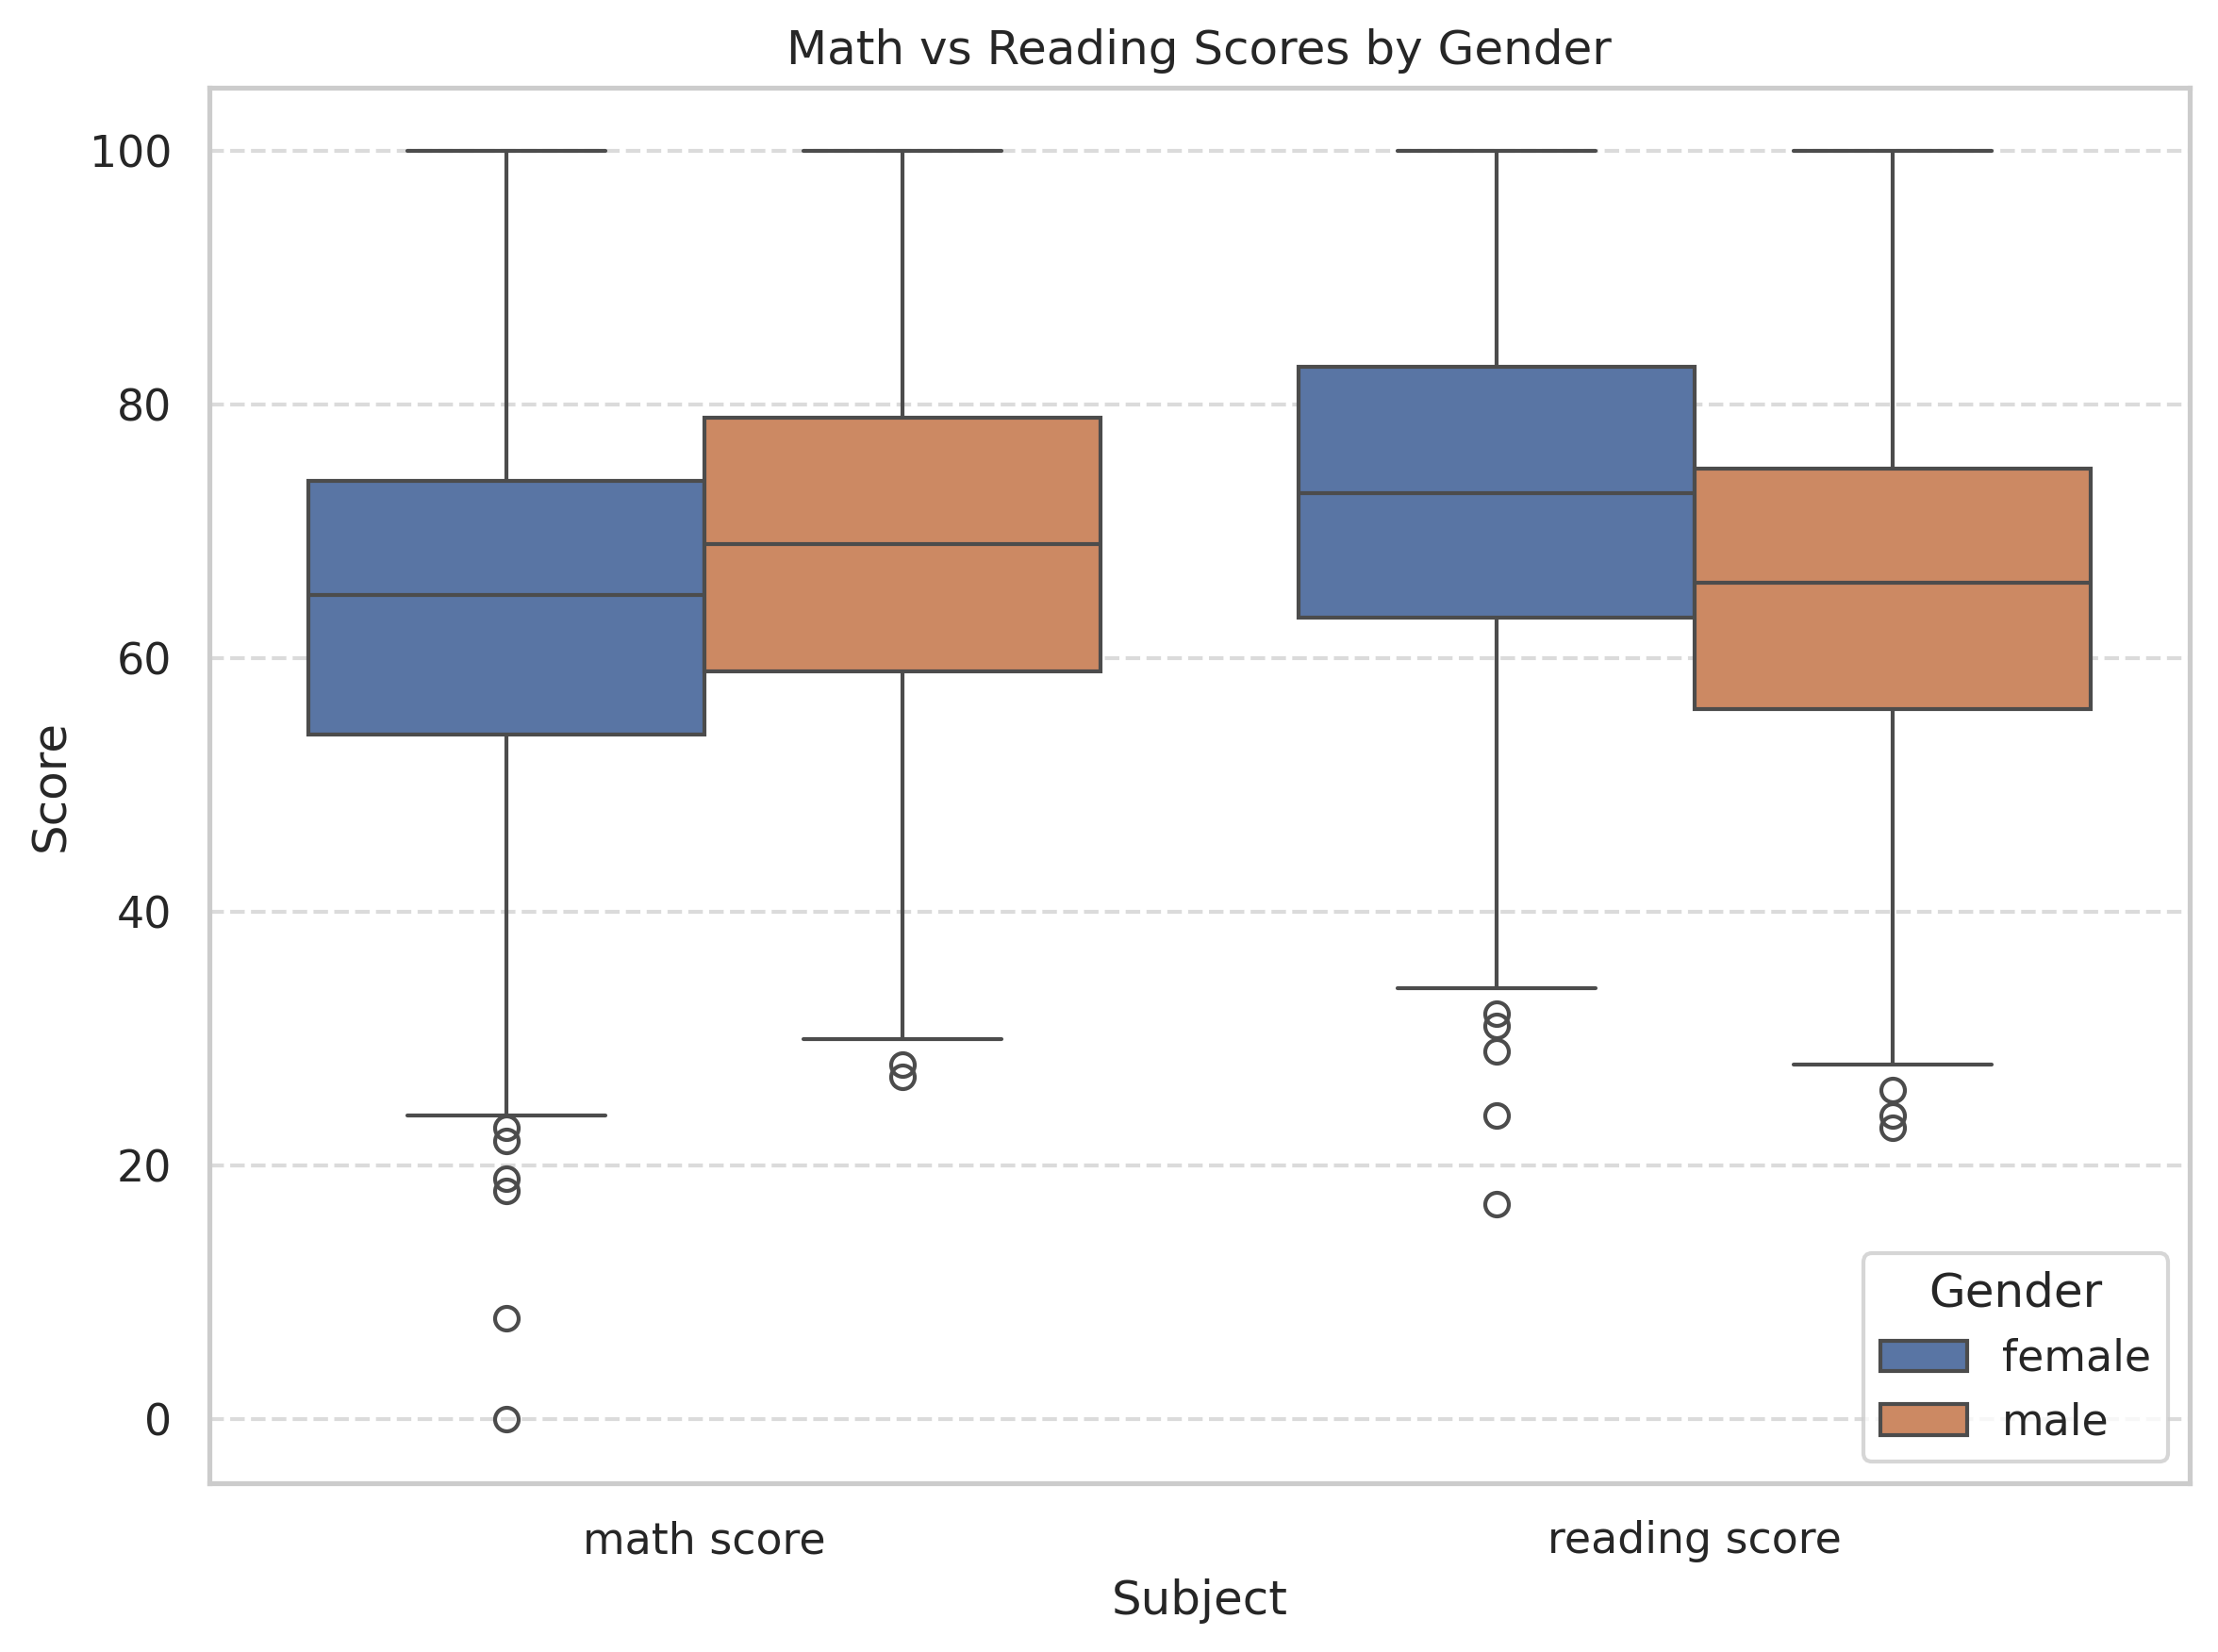

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("StudentsPerformance (1).csv")

print(df.isnull().sum())

df_melted = df.melt(id_vars="gender", value_vars=["math score", "reading score"],
                    var_name="Subject", value_name="Score")

plt.figure(figsize=(8, 6), dpi=300)
sns.boxplot(data=df_melted, x="Subject", y="Score", hue="gender")

plt.title("Math vs Reading Scores by Gender")
plt.xlabel("Subject")
plt.ylabel("Score")
plt.legend(title="Gender")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("v1_gender_boxplots.png", dpi=300)
plt.show()

# **B. V2 - Test prep impact on math**

#**A)** Students who completed the test preparation course generally achieved higher math scores compared to those who did not. The median score for the prepared group is clearly above the median of the non-prepared group. In addition, their scores are more concentrated in the upper ranges, suggesting consistent benefits from preparation. Meanwhile, students without preparation show wider variation and more low-end outliers. Although there is some overlap between the two groups, the overall trend favors the test-prep students. This indicates that structured preparation can provide an academic advantage. However, individual differences still play a role in performance outcomes.

# **B)**

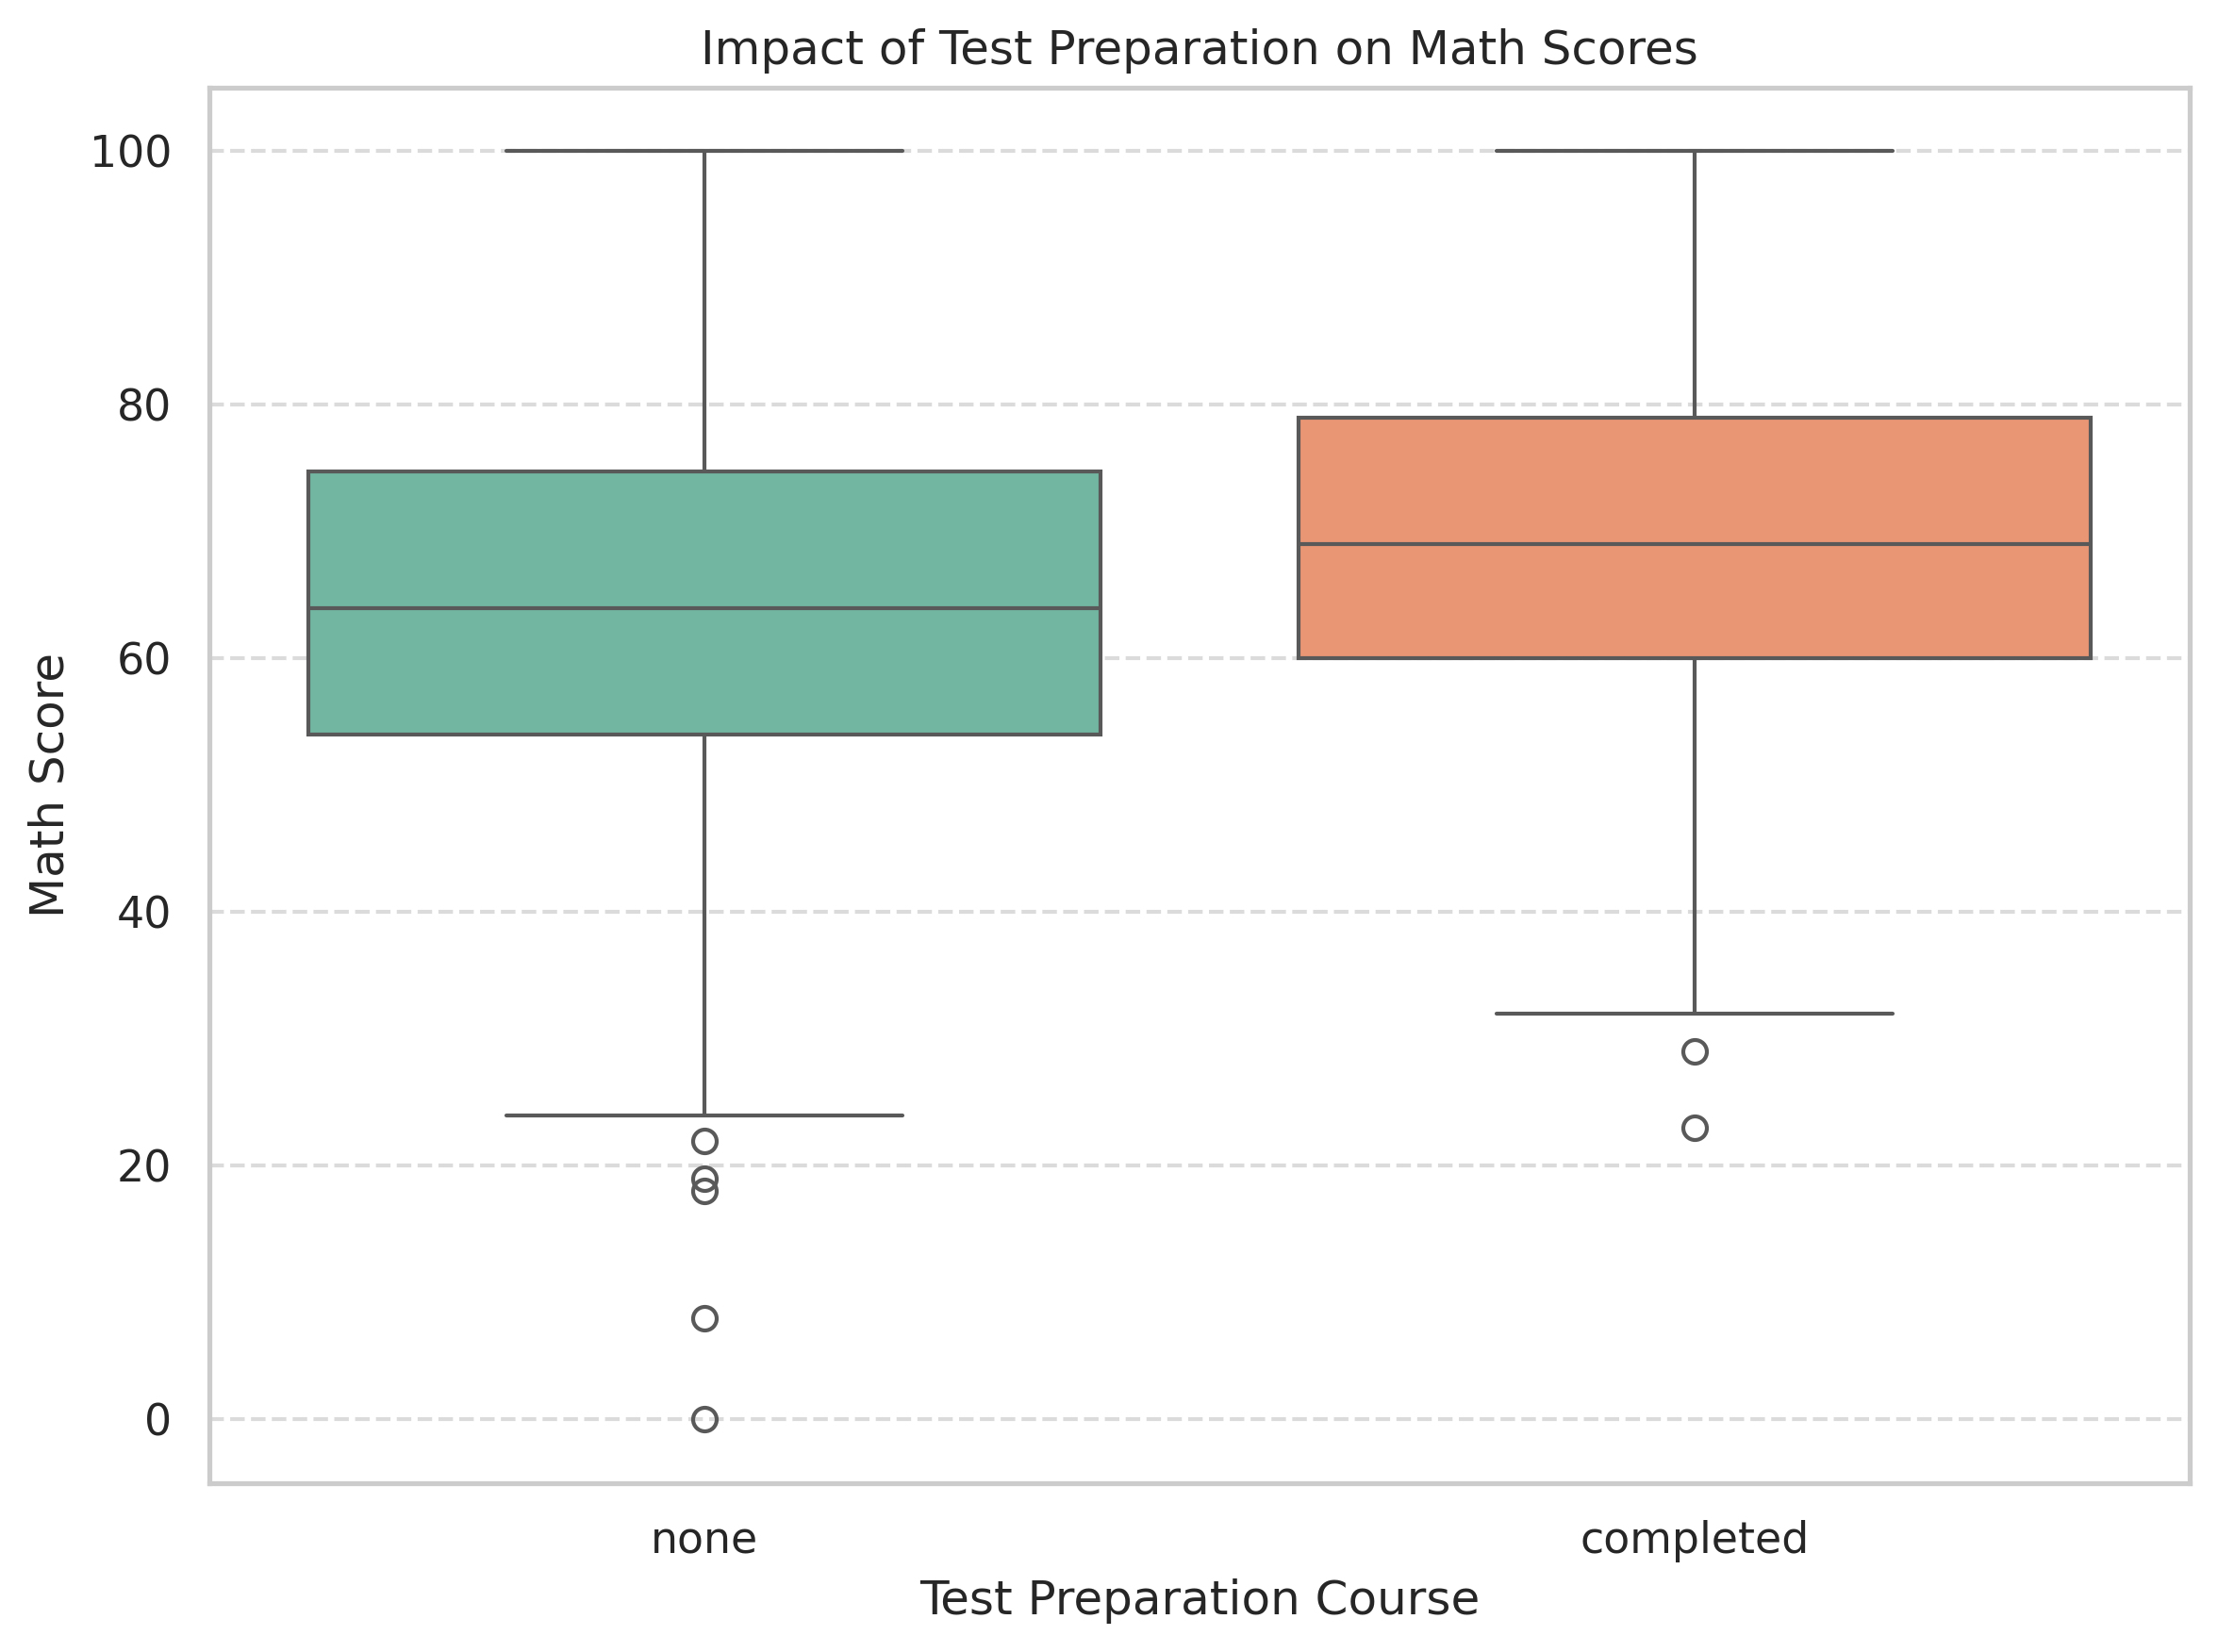

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/StudentsPerformance (1).csv")

plt.figure(figsize=(8, 6), dpi=300)
sns.boxplot(x="test preparation course", y="math score", data=df, hue="test preparation course",
            palette="Set2", dodge=False, legend=False)

plt.title("Impact of Test Preparation on Math Scores")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



# **C. V3 - Lunch type and average performance**
# **A)** Students with a standard lunch show higher average scores than those receiving free or reduced lunch. The grouped bar chart highlights this performance gap clearly. The difference suggests that nutrition or socioeconomic background may play a role in academic success. Standard lunch students consistently maintain better overall averages across math, reading, and writing. Those with free or reduced lunch often score lower, showing a possible disadvantage. The results point to external factors beyond school instruction affecting outcomes. This implies that support measures may help bridge the achievement gap.

# **B)**

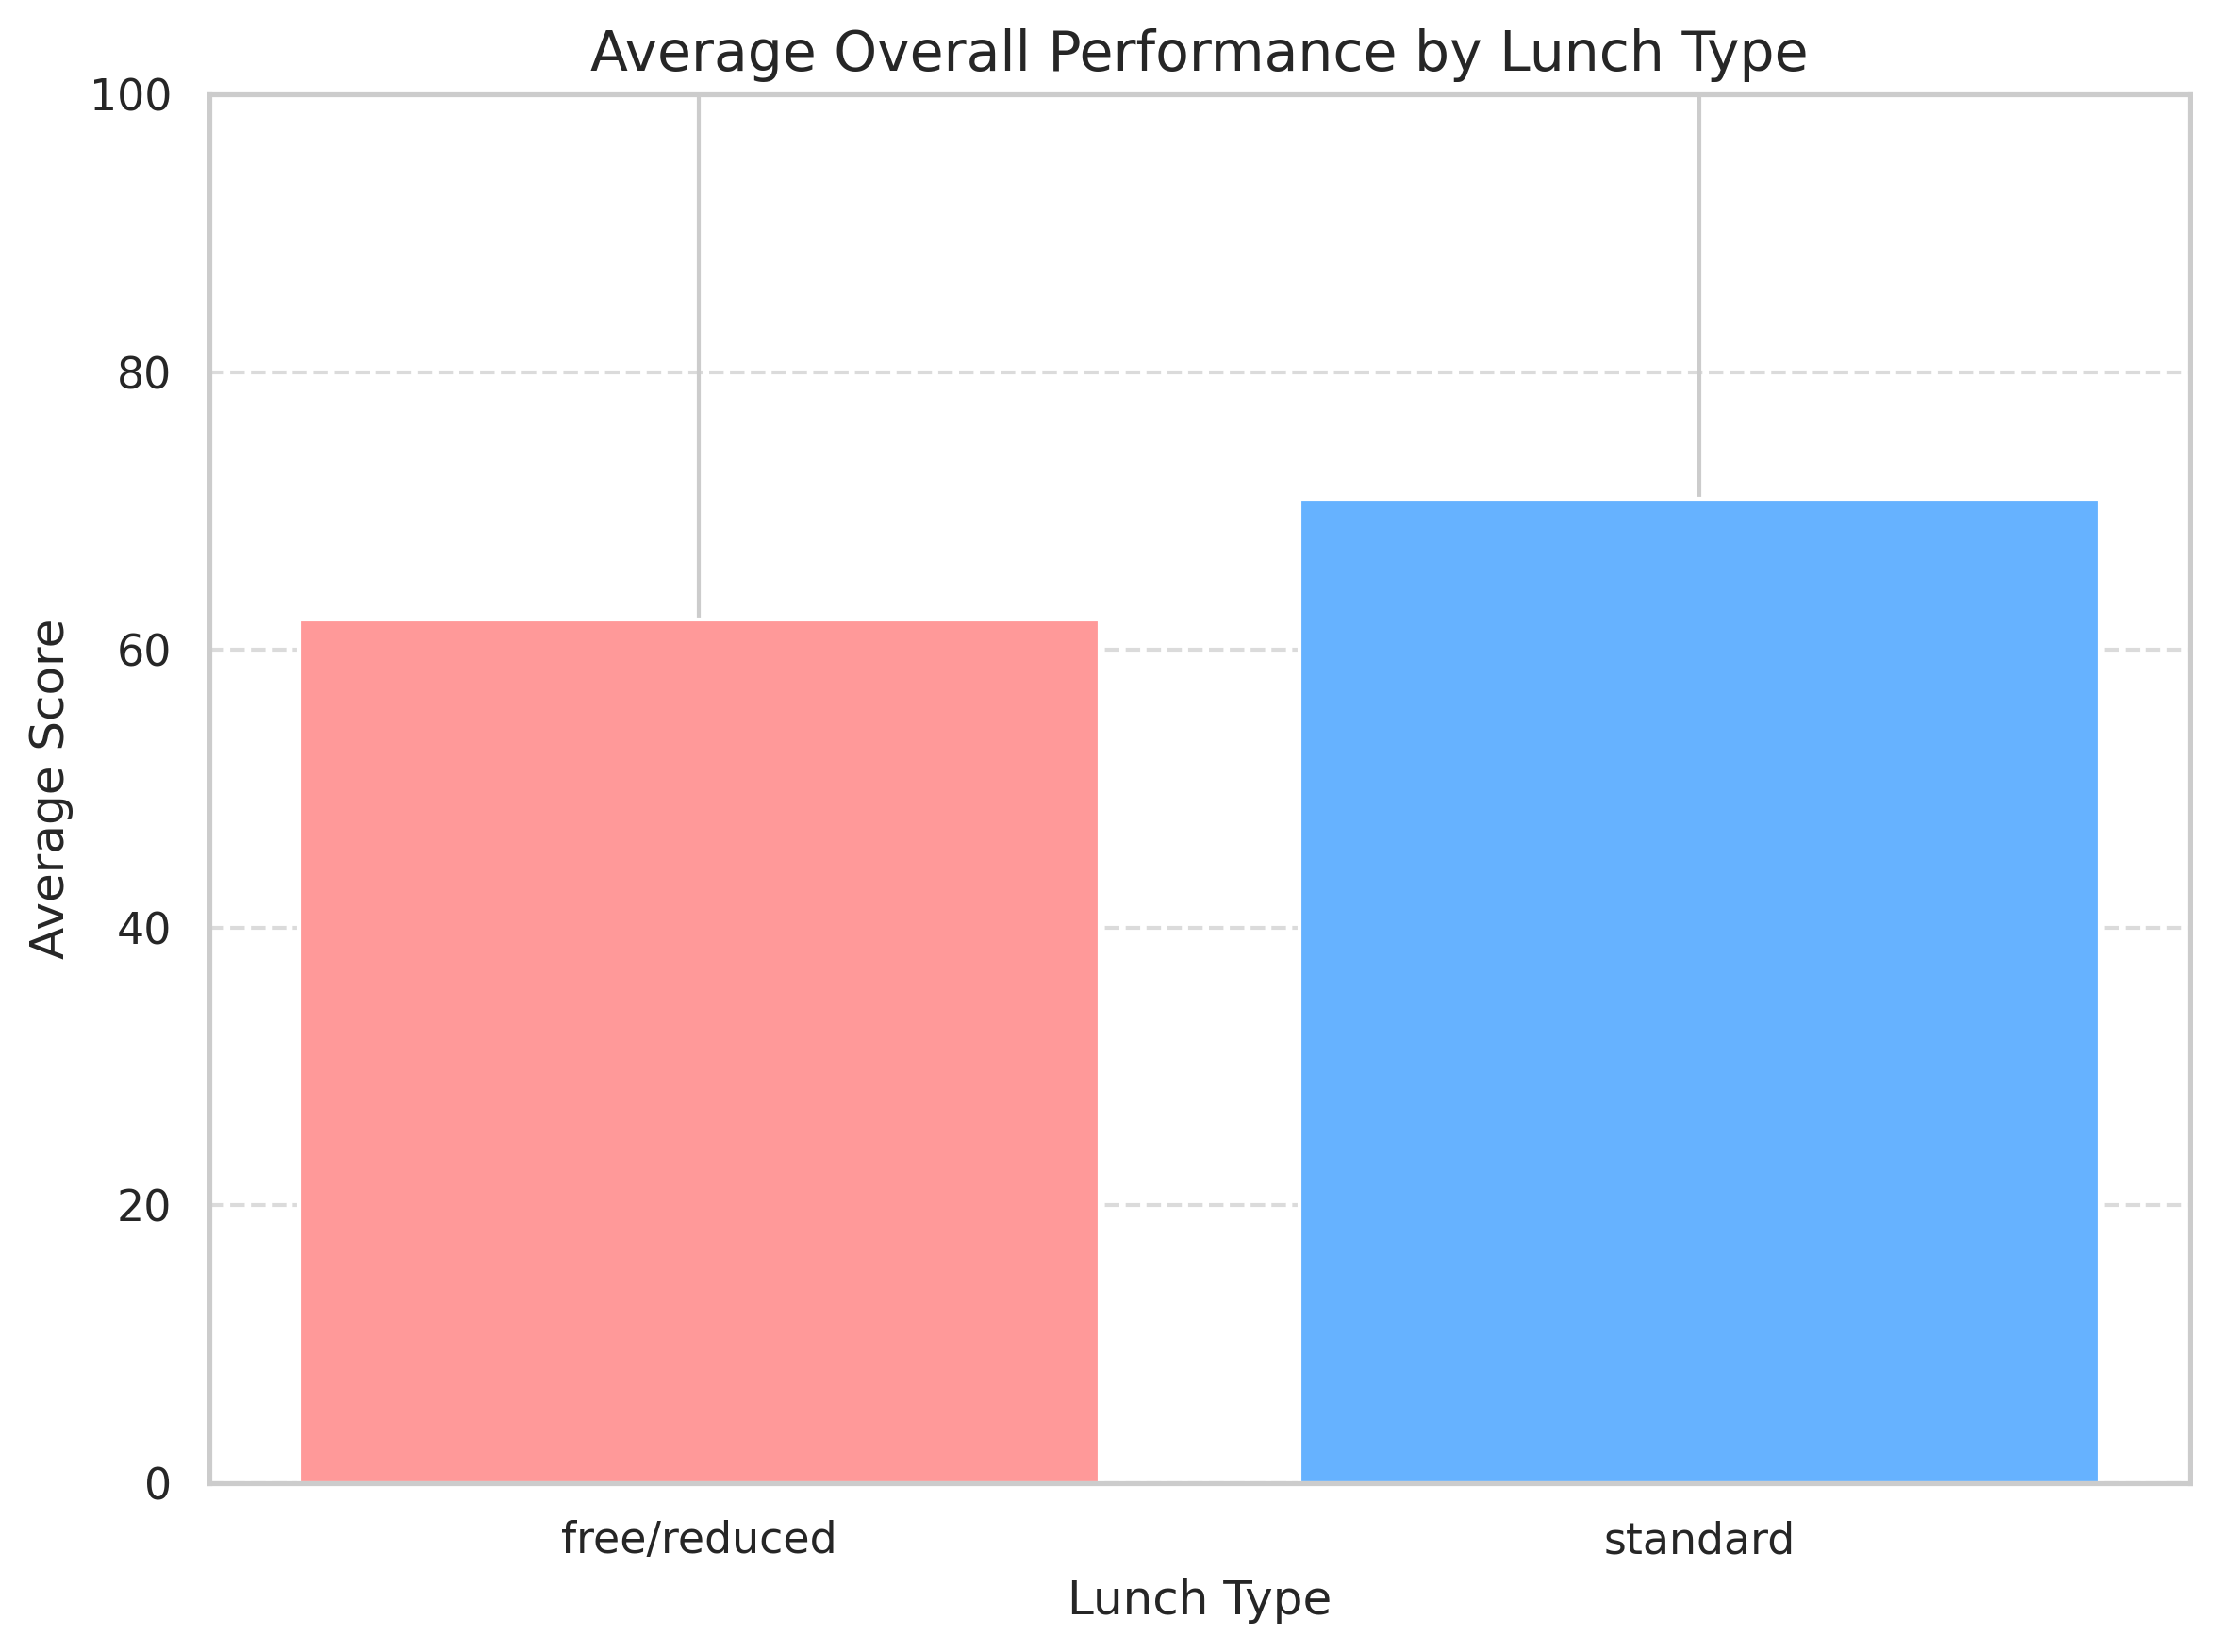

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("StudentsPerformance (1).csv")
df["overall_avg"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

avg_scores = df.groupby("lunch")["overall_avg"].mean().reset_index()

colors = ["#FF9999", "#66B2FF"]

plt.figure(figsize=(8, 6), dpi=300)
plt.bar(avg_scores["lunch"], avg_scores["overall_avg"], color=colors)

plt.title("Average Overall Performance by Lunch Type", fontsize=14)
plt.xlabel("Lunch Type", fontsize=12)
plt.ylabel("Average Score", fontsize=12)
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()




# **D. V4 - Subject correlations**

# **A)** The correlation heatmap shows that math, reading, and writing scores are strongly related. Reading and writing have the highest positive correlation, meaning students who perform well in one are very likely to do well in the other. Math also shows a strong positive relationship with both reading and writing, though slightly weaker than the reading writing link. This indicates that academic strengths often extend across subjects rather than being isolated. The consistently high correlations suggest that core skills like comprehension, reasoning, and practice may influence all three areas. Students who struggle in one subject may need support across multiple subjects. Overall, the heatmap highlights how interconnected academic performance is across different areas.

# **B)**

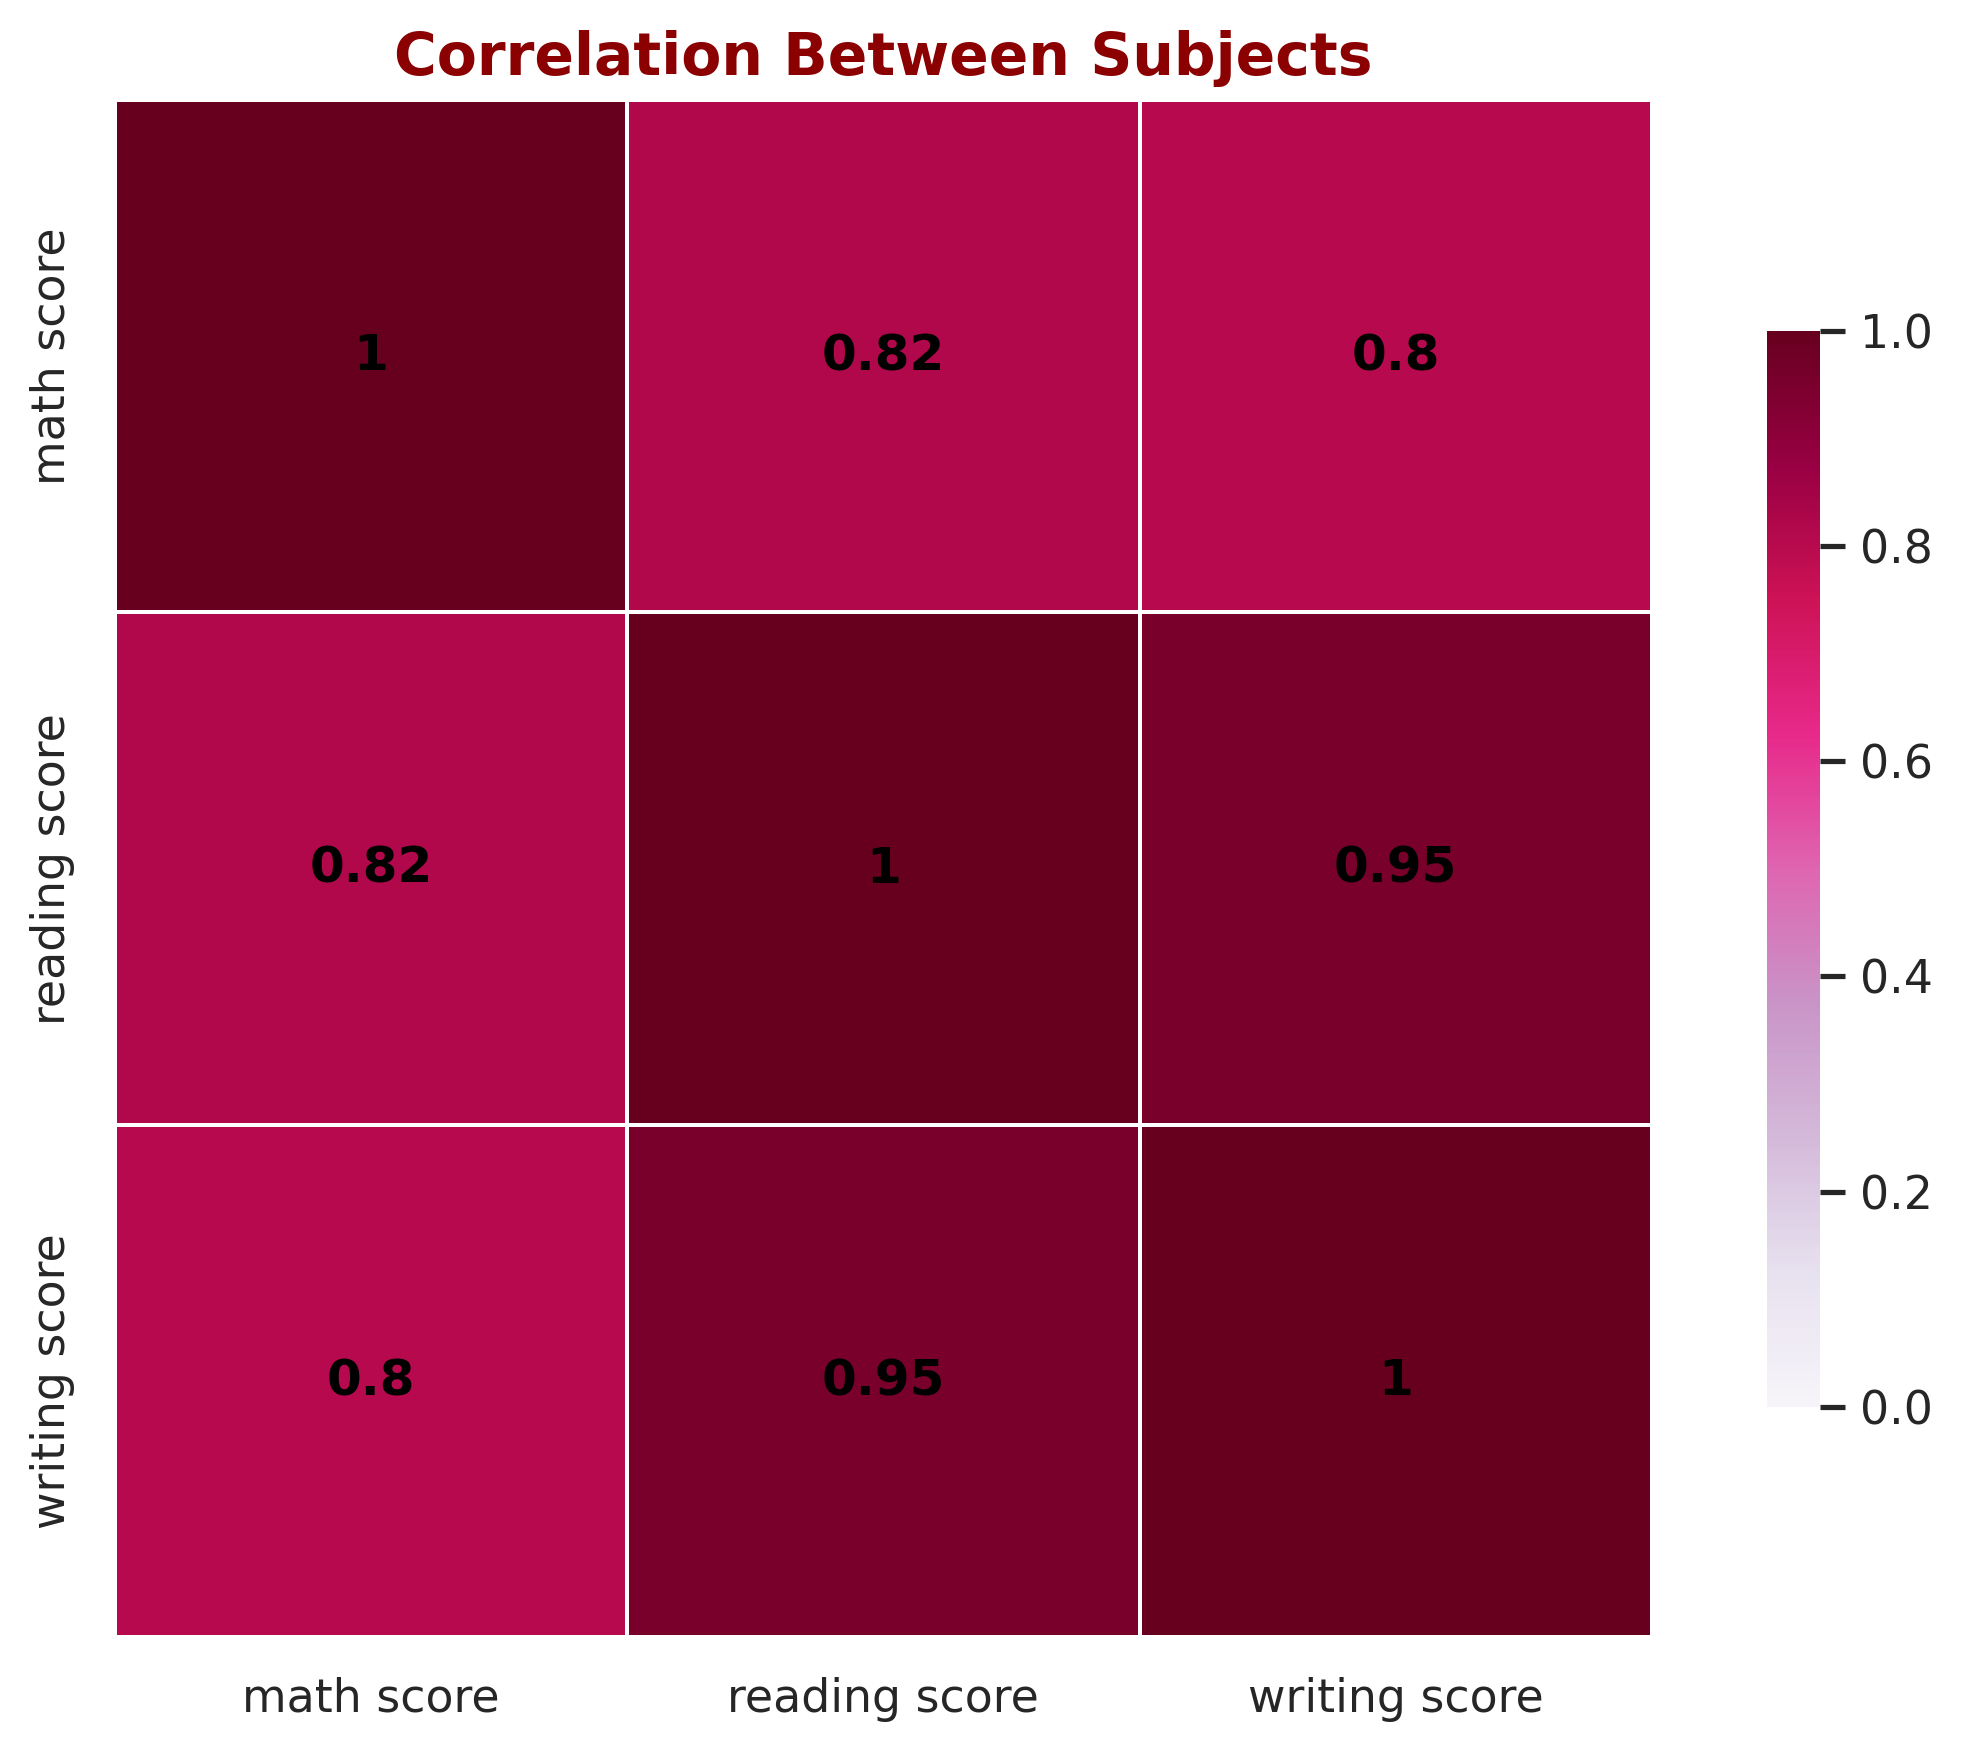

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("StudentsPerformance (1).csv")

subjects = df[["math score", "reading score", "writing score"]]

corr = subjects.corr()

plt.figure(figsize=(8, 6), dpi=300)
sns.heatmap(corr, annot=True, cmap="PuRd", vmin=0, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.7},
            annot_kws={"size": 12, "weight": "bold", "color": "black"})

plt.title("Correlation Between Subjects", fontsize=14, weight="bold", color="darkred")
plt.tight_layout()
plt.show()





# **E. V5 — Math vs reading with trend lines by test prep**


# **A)** The scatter plot shows a strong positive relationship between math and reading scores. As reading scores increase, math scores also tend to rise for most students.Both groups (completed and none) follow this upward trend, indicating strong association. Students who completed the test-preparation course generally achieve higher scores. The slope for the completed group is slightly steeper than the none group. This suggests the course may help boost performance in both subjects. Overall, math and reading abilities appear strongly linked, with test prep providing an advantage.

# **B)**

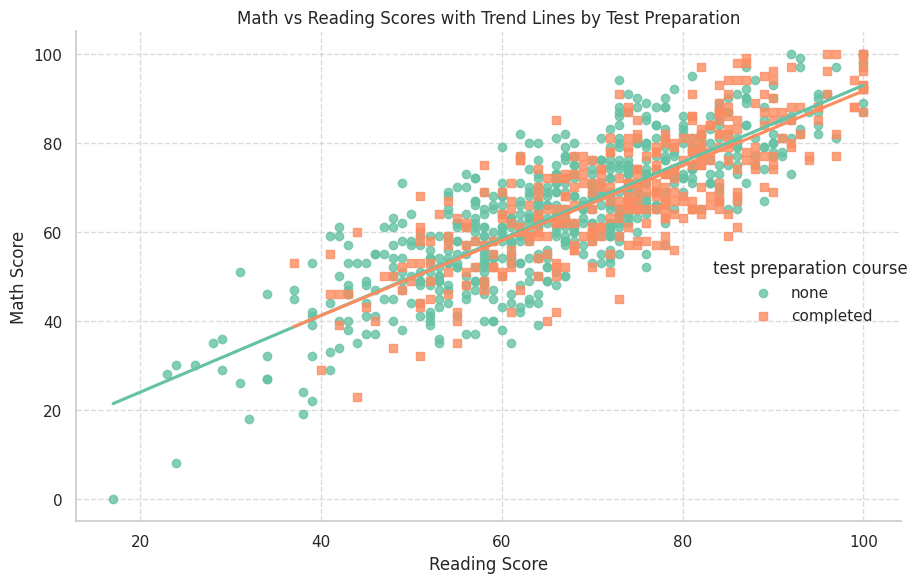

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("StudentsPerformance (1).csv")

sns.lmplot(data=df, x="reading score", y="math score",
           hue="test preparation course", palette="Set2",
           height=6, aspect=1.2, markers=["o", "s"], ci=None)

plt.title("Math vs Reading Scores with Trend Lines by Test Preparation")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.grid(axis="both", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


# **C)**

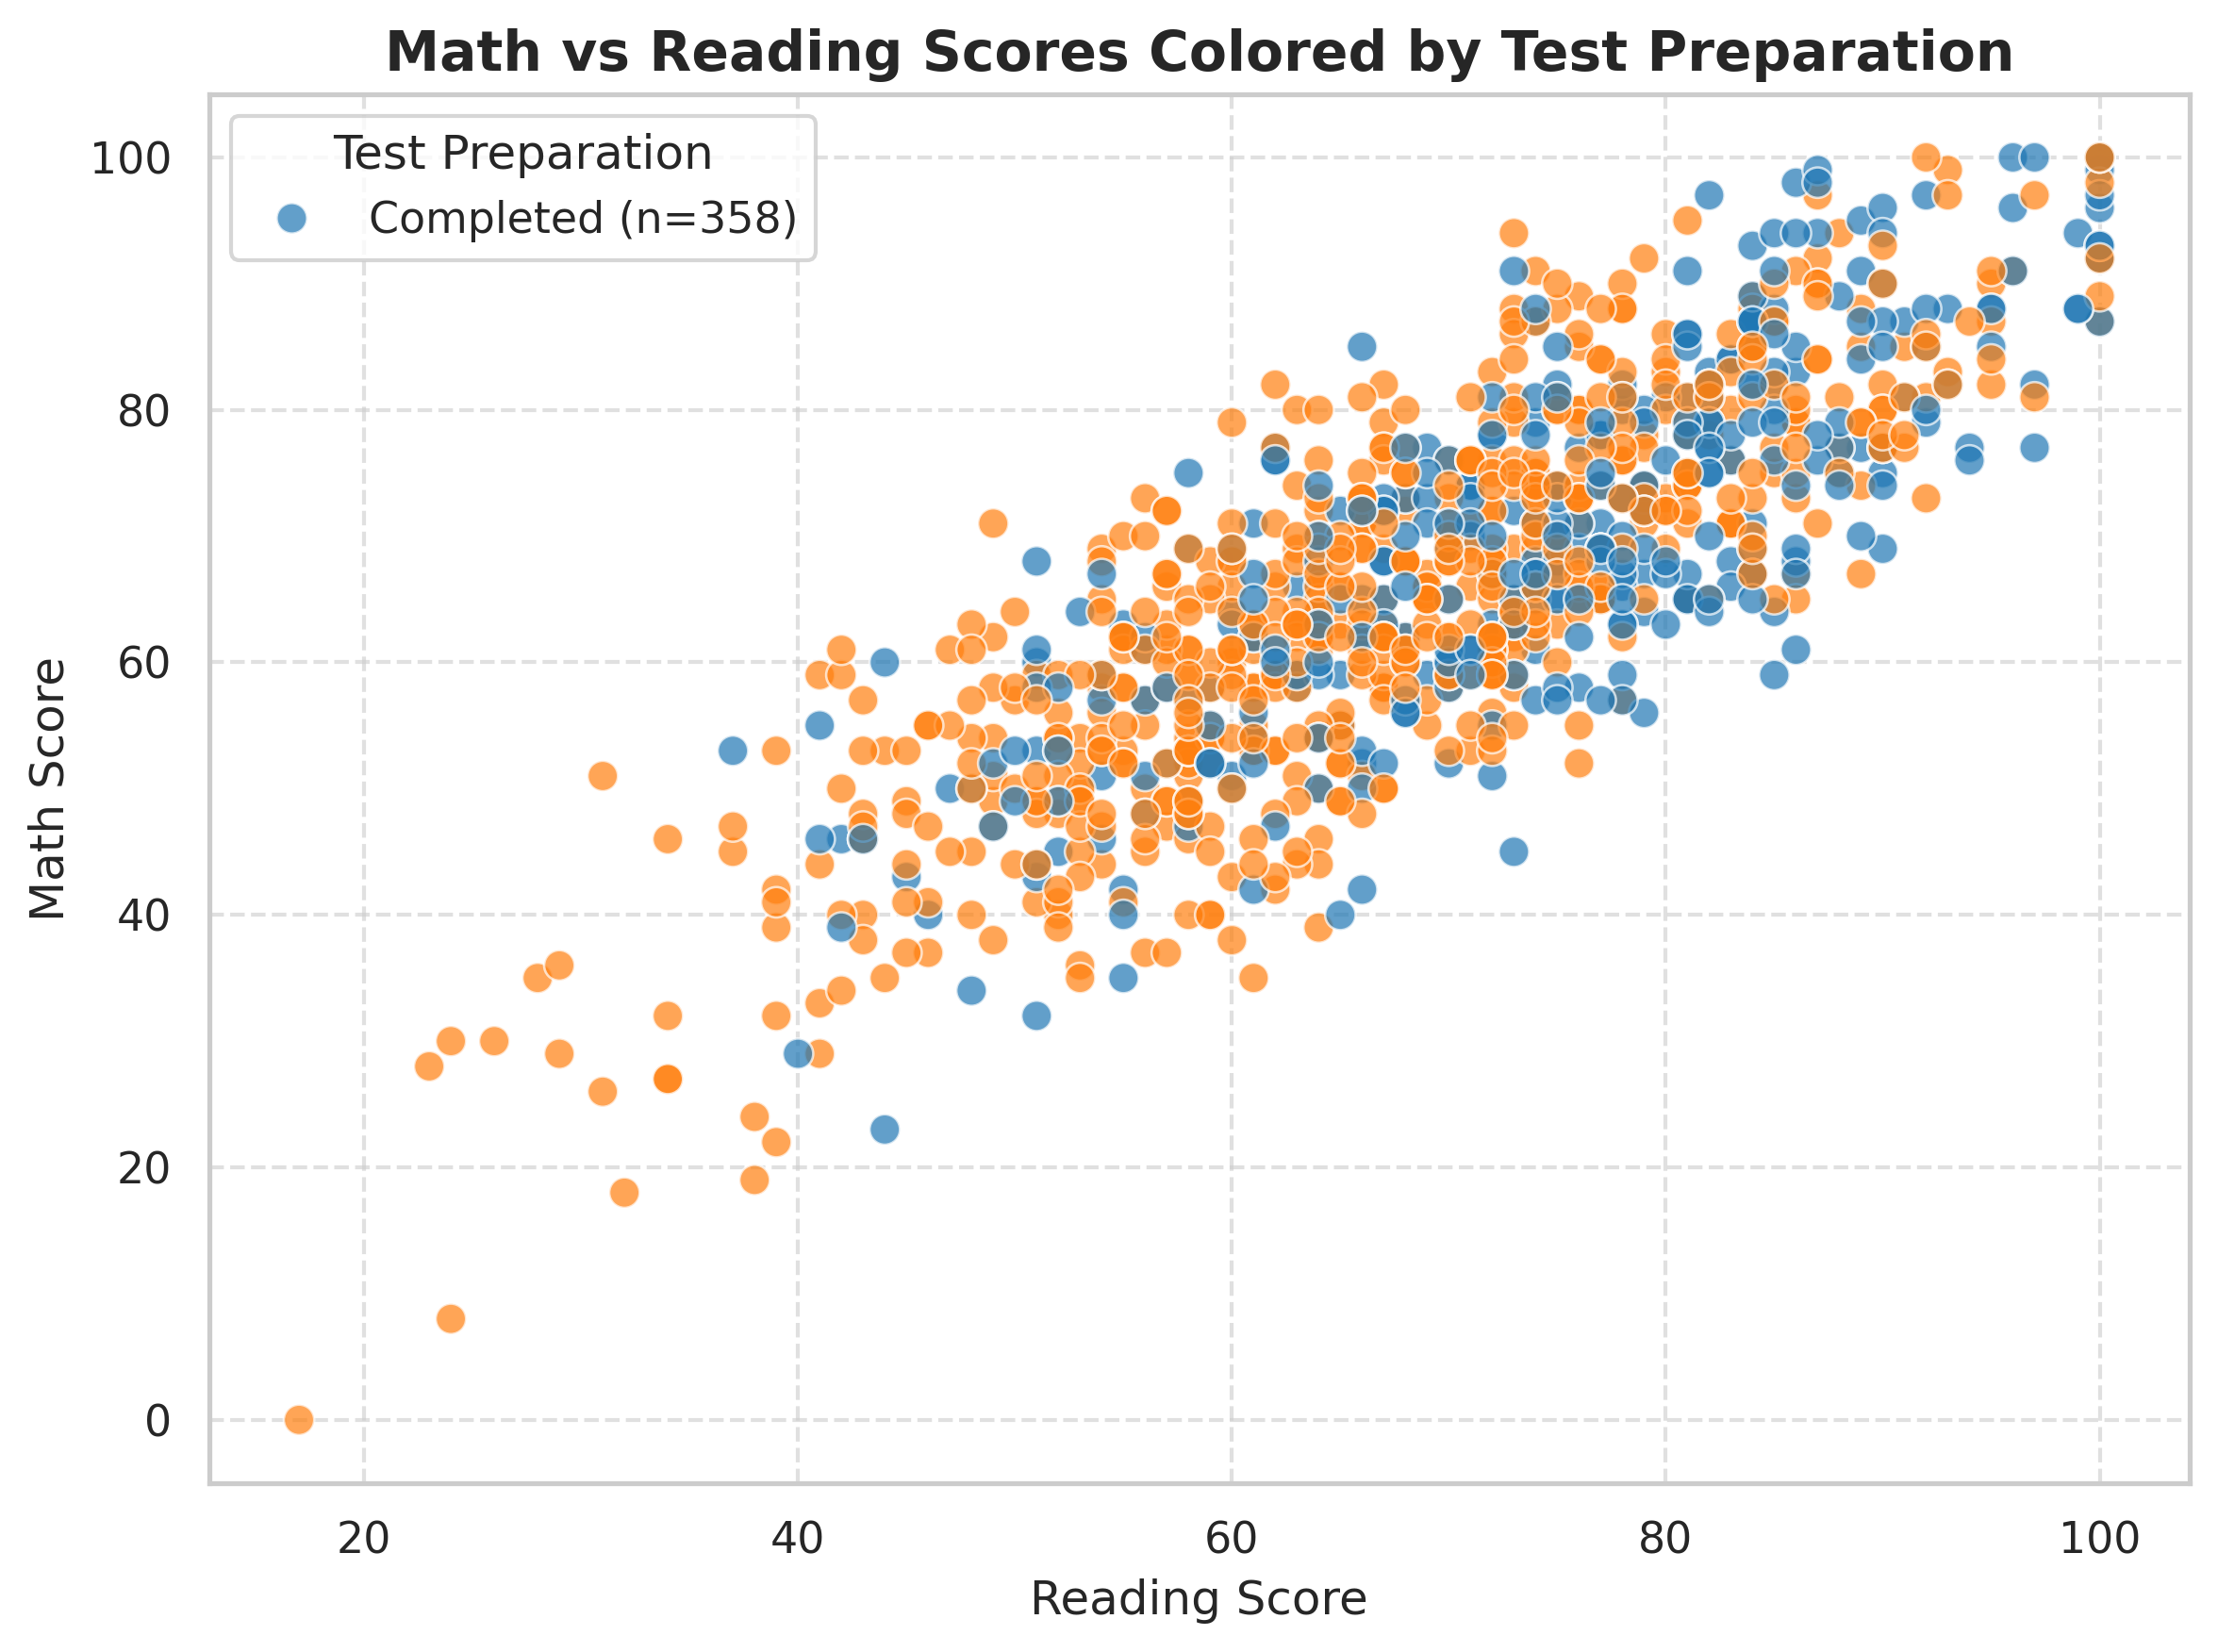

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("StudentsPerformance (1).csv")

group_counts = df["test preparation course"].value_counts()

plt.figure(figsize=(8, 6), dpi=300)
sns.scatterplot(
    data=df,
    x="reading score",
    y="math score",
    hue="test preparation course",
    palette={"completed": "#1f77b4", "none": "#ff7f0e"},
    alpha=0.7,
    s=60
)

handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [
    f"Completed (n={group_counts['completed']})",
    f"None (n={group_counts['none']})"
]
plt.legend(handles[1:], new_labels, title="Test Preparation", loc="upper left")

plt.title("Math vs Reading Scores Colored by Test Preparation", fontsize=14, weight="bold")
plt.xlabel("Reading Score", fontsize=12)
plt.ylabel("Math Score", fontsize=12)
plt.grid(axis="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
